# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?


*   A linear model has a response (dependent) variable y predicted by a vector of features $(x_1,...,x_L)$ and usually a bias term $b_0$. Here we are looking to find the best linear predictor.

The linear model, $y=\beta_0+\beta_1x_1+...+\beta_Lx_L$, seeks to predictor a response (dependent) variable $y$ by a vector of features $(x_1,...,x_L)$ and usually a bias term $b_0$. The coefficients (model parameters) $b_0,b_1,...,b_L$ are linear. The variables $x_1,...,x_L$ don't necessarily have to be linear in nature, however we might consider transformations such that our model achieves linearity.



2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
*   The interpreation of a coefficient for a dummy/one-hot-encoded variable is dependent on whether or not it an intercept is included. If we have an intercept, meaning we have a baseline, the coefficient can be interpretated as 'the difference in the mean outcome of the response, relative to the baseline'. Here we chose a category/condition of the variable to serve as the baseline. If we do not have an intercept, meaning we have included all dummy varibales, each coefficent can be interpretated as 'the mean response for that category'. If we have all dummies and an intercept, we have a case of perfect multicollinearity.
3. Can linear regression be used for classification? Explain why, or why not.
*   Linear regression should be used for prediction, not classification. While it is possible, it is not appropriate because linear regression predicts continuos values, not probablities, meaning that our prediction outcomes can lie outside the [0,1] which is not possible in probablistic terms. Additionally, our assumptions for constant variance and normality don't hold for binary outcomes. For classification purposes, we prefer logistic regression instead.

4. What are signs that your linear model is over-fitting?
*   Some signs that our linear model is overfitting is that it has a high $R^2$ on training data, but a low $R^2$ on test or validation data . Again, low training RMSE, high test RMSE. We should also look for excessive features (compare to sample size), fluctuation in prediction, and high-degree polynomial fits.
5. Clearly explain multi-colinearity using the two-stage least squares technique.
*   Multi-colinearity occurs when a set of predictors are highly correlated, capturing the same noise and therefore explaining the same information. Let $x_i, x_j$ be two highly correlated variables in our model. In the two-stage least squares technique we first regress $x_i$ on $x_j$ to get residuals $e_i$, which explain what is unquie in $x_i$. We then use $e_i$ in the main regression. Thus, two-stage least squares effectively orthogonalizes our variables $x_i,x_j$, such that they are now uncorrelated in our regression model and can resolve an issue of multi-colinearity.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
*   If we want to incorporate nonlinear relationships, we will commonly transform the features. Approaches that we have discuess is log-transformation, arc-sinh transformation, or adding interaction terms. For a linear model, we need to maintain linearity in our coefficients, but not necessarily in our features.
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?
*   Interpretation for the intercept, $b_0$: it is the expected calue of $y$ when all precitors = 0
*   For slope coefficient of $b_i$: The change in $y$ for a one unit increase in $x_i$, given all other variables remain constant
*   For dummy/one-hot-encoded variable:

With intercept: the difference in the mean outcome of the response, relative to the baseline; or more simply put, the difference from the baseline group

Without intercept: the mean response for that category.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


   neighbourhood   avg_price  avg_review_score      n
2      Manhattan  183.664286         91.801496  11763
4  Staten Island  146.166667         90.843750     96
1       Brooklyn  127.747378         92.363497   8487
3         Queens   96.857233         91.549057   1590
0          Bronx   75.276498         91.654378    217
Most expensive borough on average:
neighbourhood        Manhattan
avg_price           183.664286
avg_review_score     91.801496
n                        11763
Name: 2, dtype: object


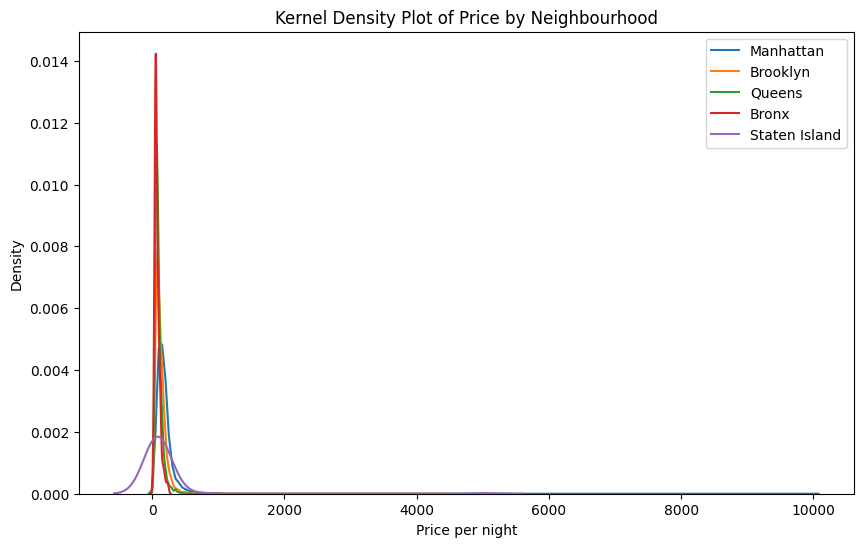

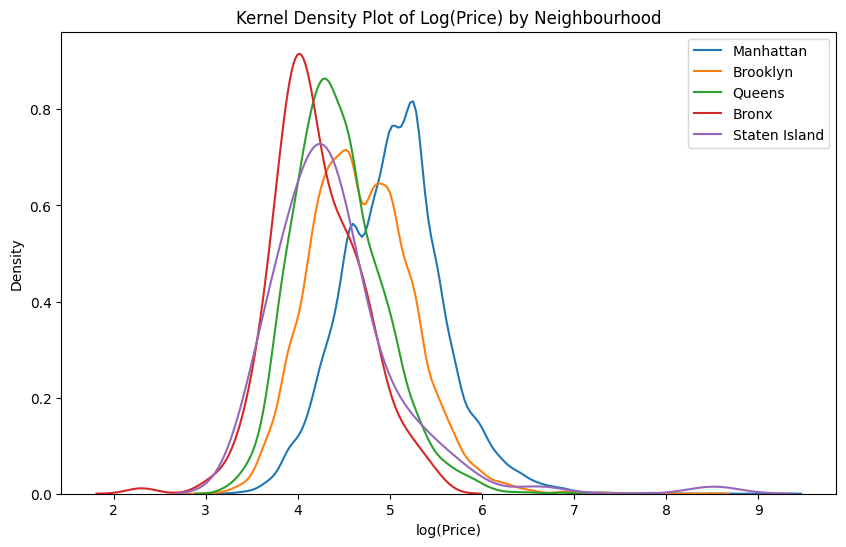

In [2]:
# part 1 code
# compute avg prices and score by neighbourhood
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

q1_df = pd.read_csv('/content/drive/MyDrive/DS3001/data/Q1_clean.csv')
# Clean up column names by stripping whitespace and converting to lowercase for consistency
q1_df.columns = q1_df.columns.str.strip().str.lower().str.replace(' ', '_')
q1_df.head()
# some summary stats on neighbourhood
neigh_sum = (
    q1_df.groupby("neighbourhood").agg(
        avg_price=("price", "mean"),
        avg_review_score=("review_scores_rating", "mean"),
        n=("price", "size")).reset_index().sort_values("avg_price", ascending=False))
print(neigh_sum)
# most expensive borough avg
print("Most expensive borough on average:")
print(neigh_sum.iloc[0])
# KDE of price by neighbourhood
plt.figure(figsize=(10, 6))
for b in q1_df["neighbourhood"].dropna().unique():
    subset = q1_df.loc[q1_df["neighbourhood"] == b, "price"].dropna()
    sns.kdeplot(subset, label=b, fill=False)
plt.title("Kernel Density Plot of Price by Neighbourhood")
plt.xlabel("Price per night")
plt.ylabel("Density")
plt.legend()
plt.show()
# log KDE
# keep only positive prices before taking logs
q1_df_log = q1_df[q1_df["price"] > 0].copy()
q1_df_log["log_price"] = np.log(q1_df_log["price"])
plt.figure(figsize=(10, 6))
for b in q1_df_log["neighbourhood"].dropna().unique():
    subset = q1_df_log.loc[q1_df_log["neighbourhood"] == b,
                           "log_price"].dropna()
    sns.kdeplot(subset, label=b, fill=False)
plt.title("Kernel Density Plot of Log(Price) by Neighbourhood")
plt.xlabel("log(Price)")
plt.ylabel("Density")
plt.legend()
plt.show()


2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

In [41]:
# part 2 code
# create dummies for all neighbourhoods
X2 = pd.get_dummies(q1_df["neighbourhood"], prefix="neigh", drop_first=False)
y = q1_df["price"]
# fit model without intercept
model2 = LinearRegression(fit_intercept=False)
model2.fit(X2, y)
coef_part2 = pd.Series(model2.coef_, index=X2.columns)
print(coef_part2)

neigh_Bronx             75.276498
neigh_Brooklyn         127.747378
neigh_Manhattan        183.664286
neigh_Queens            96.857233
neigh_Staten Island    146.166667
dtype: float64



3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

In [23]:
# part 3 code
# create dummies but drop one category as the reference
X3 = pd.get_dummies(q1_df["neighbourhood"], prefix="neigh", drop_first=True)
model3 = LinearRegression(fit_intercept=True)
model3.fit(X3, y)
print("Intercept:", model3.intercept_)
coef_part3 = pd.Series(model3.coef_, index=X3.columns)
print(coef_part3)
# to see reference group
print(sorted(q1_df["neighbourhood"].dropna().unique()))

Intercept: 75.27649769585331
neigh_Brooklyn          52.470881
neigh_Manhattan        108.387789
neigh_Queens            21.580735
neigh_Staten Island     70.890169
dtype: float64
['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']



4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [42]:
# part 4 code
df4 = q1_df[["price", "review_scores_rating", "neighbourhood"]].dropna().copy()
train4, test4 = train_test_split(df4, test_size=0.2, random_state=123)
# build design matrics
X_train4 = pd.get_dummies(train4[["review_scores_rating", "neighbourhood"]], drop_first=True)
X_test4 = pd.get_dummies(test4[["review_scores_rating", "neighbourhood"]], drop_first=True)
# make sure train and test have same columns
X_train4, X_test4 = X_train4.align(X_test4, join="left", axis=1, fill_value=0)
y_train4 = train4["price"]
y_test4 = test4["price"]
# fit model
model4 = LinearRegression()
model4.fit(X_train4, y_train4)
pred4 = model4.predict(X_test4)
r2_4 = r2_score(y_test4, pred4)
rmse_4 = np.sqrt(mean_squared_error(y_test4, pred4))
print("Test R^2:", r2_4)
print("Test RMSE:", rmse_4)
# coeff on review_score
print("Coeff on review score:", model4.coef_[0])
property_avg = (
    q1_df.groupby("property_type")["price"].mean().sort_values(ascending=False).head(1))
print("Most expensive property to rent:", property_avg)

Test R^2: 0.03953256032941743
Test RMSE: 131.3987732306601
Coeff on review score: 1.200211259492264
Most expensive property to rent: property_type
Condominium    241.229167
Name: price, dtype: float64



5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [43]:
# part 5 code
df5 = q1_df[["price", "review_scores_rating", "neighbourhood", "property_type"]].dropna().copy()
train5, test5 = train_test_split(df5, test_size=0.2, random_state=123)
# create predictors
X_train5 = pd.get_dummies(
    train5[["review_scores_rating", "neighbourhood", "property_type"]],drop_first=True)
X_test5 = pd.get_dummies(
    test5[["review_scores_rating", "neighbourhood", "property_type"]], drop_first=True)
X_train5, X_test5 = X_train5.align(X_test5, join="left", axis=1, fill_value=0)
y_train5 = train5["price"]
y_test5 = test5["price"]
# fit and eval
model5 = LinearRegression()
model5.fit(X_train5, y_train5)
pred5 = model5.predict(X_test5)
r2_5 = r2_score(y_test5, pred5)
rmse_5 = np.sqrt(mean_squared_error(y_test5, pred5))
print("Test R^2:", r2_5)
print("Test RMSE:", rmse_5)
# coeff on review_score
# coeff on review_score
print("Coeff on review score:", model5.coef_[0])
coef5 = pd.Series(model5.coef_, index=X_train5.columns)
print(coef5.sort_values(ascending=False).head(1))

Test R^2: 0.04478435230915112
Test RMSE: 131.0390395671991
Coeff on review score: 1.1904579364034942
neighbourhood_Manhattan    122.711851
dtype: float64



6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.

In part 4, the coefficient on review scores rating measures the relationship between review score and price, while only controlling for neighbourhood. In part 5, the model additionally controls for property type. The change in coefficient means that property type is correlated with to both review score and price. This suggest that by omitting property type in part 4, we introduced bias into the estimated effect of review scores.


7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [47]:
q1_df['neigh_prop'] = q1_df["neighbourhood"] + " | " + q1_df['property_type']
X = q1_df[['neigh_prop', "review_scores_rating"]]
y = q1_df['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train_dummies = pd.get_dummies(X_train['neigh_prop'], drop_first=True)
X_test_dummies = pd.get_dummies(X_test['neigh_prop'], drop_first=True)
# align cols
X_train_dummies, X_test_dummies = X_train_dummies.align(
    X_test_dummies, join='left', axis=1, fill_value=0)
X_train_final = pd.concat([
    X_train_dummies.reset_index(drop=True),
    X_train["review_scores_rating"].reset_index(drop=True)], axis=1)
X_test_final = pd.concat([
    X_test_dummies.reset_index(drop=True),
    X_test["review_scores_rating"].reset_index(drop=True)], axis=1)
model_interact = LinearRegression()
model_interact.fit(X_train_final, y_train)

yhat_test = model_interact.predict(X_test_final)

r2_test = r2_score(y_test, yhat_test)
rmse_test = np.sqrt(mean_squared_error(y_test, yhat_test))

print("Interaction model")
print("Test R2:", r2_test)
print("Test RMSE:", rmse_test)

Interaction model
Test R2: 0.054558809011923226
Test RMSE: 140.27921411459138


The interaction model produces a slight increase in test $R^2$, indicating imporvement in explained information/variance. However, the test RMSE also increases which suggests the predition accuracy has worsened. Because $R^2$ will always increase with the addition of terms, the value of RMSE indicates that the added complexity does not explain a significant amount more of variation in the model, and the interaction model may be overfitting the data.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.


   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
Unnamed: 0            int64
Make

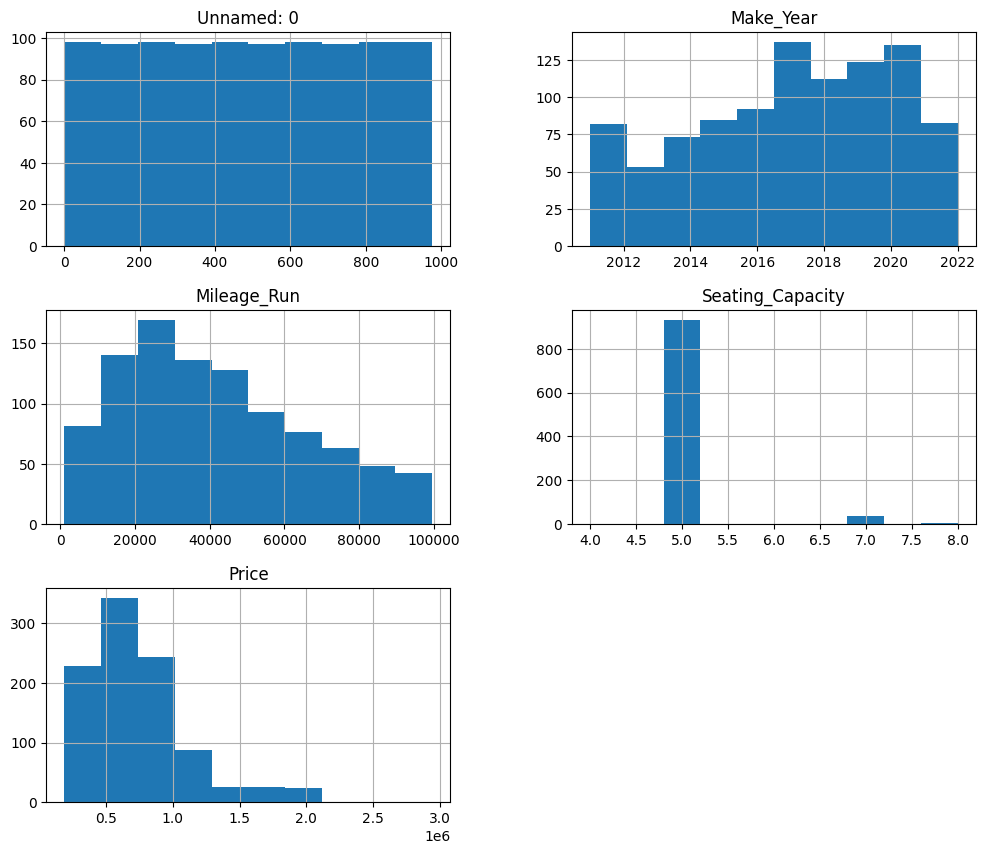

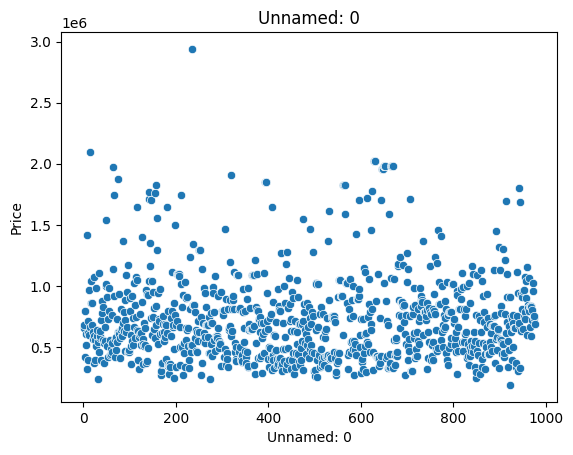

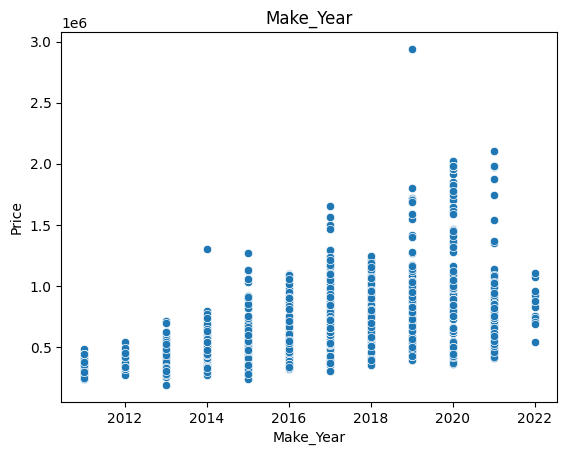

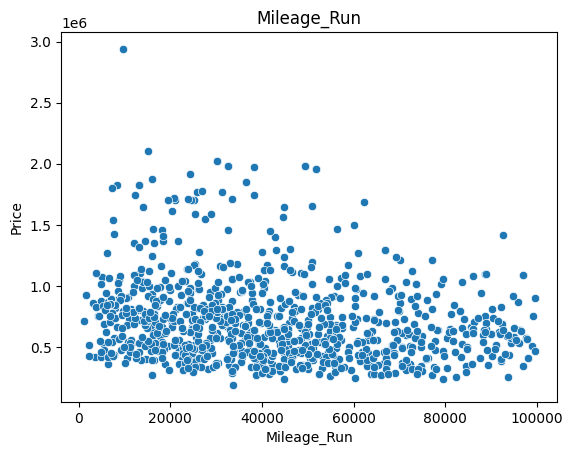

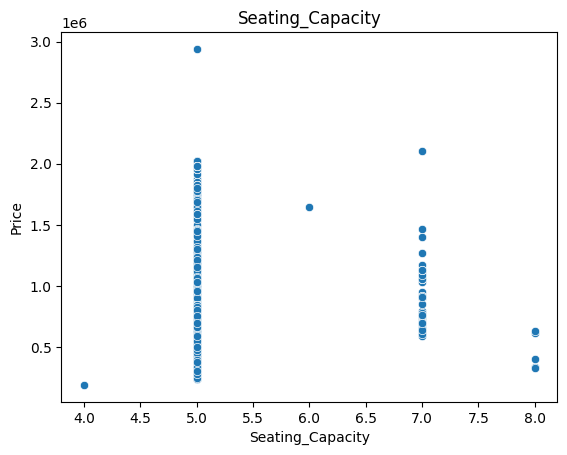

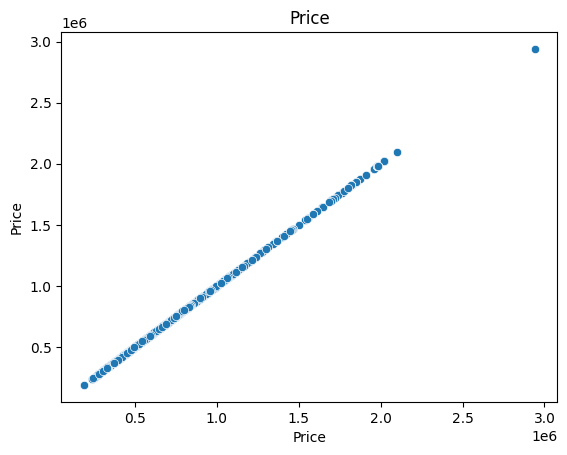

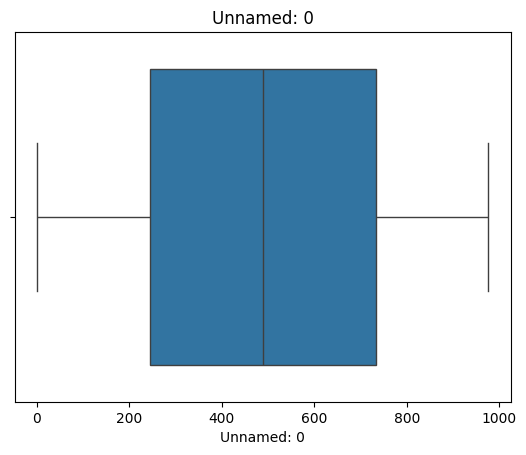

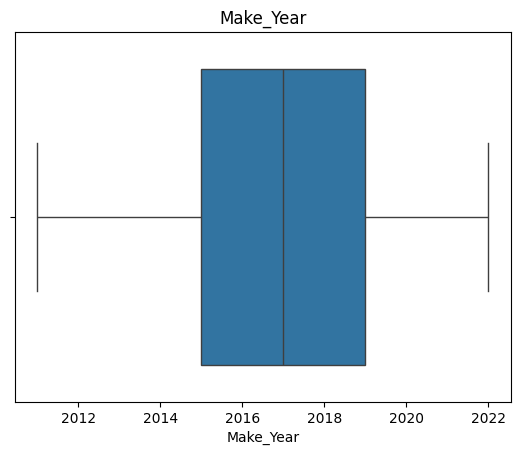

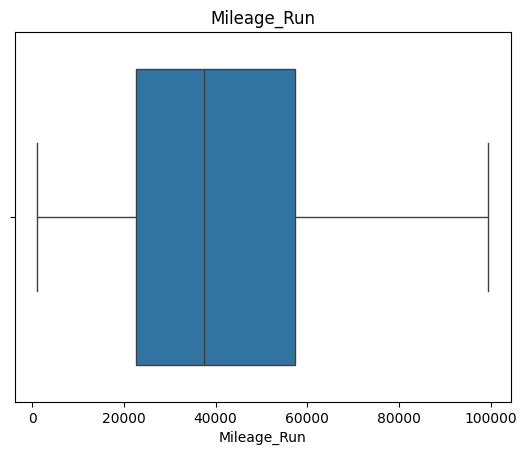

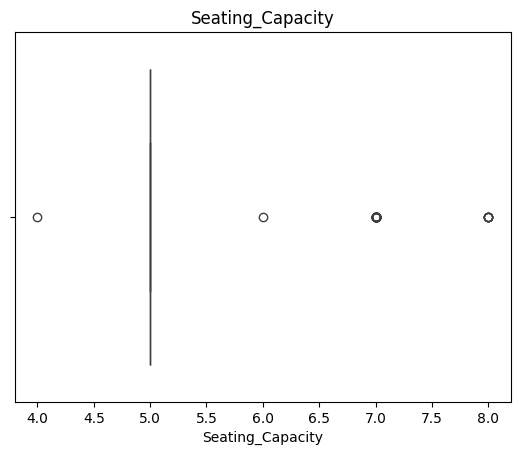

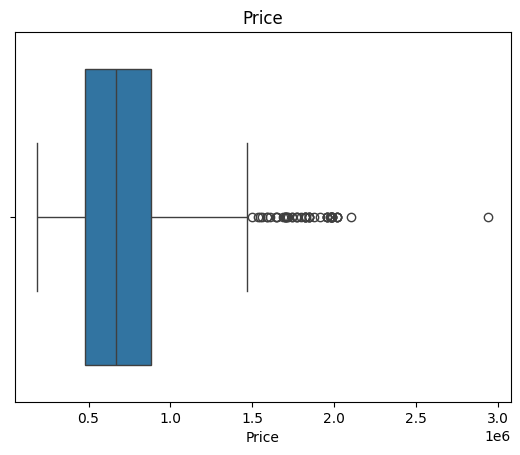

<Axes: xlabel='Make_Year', ylabel='Price'>

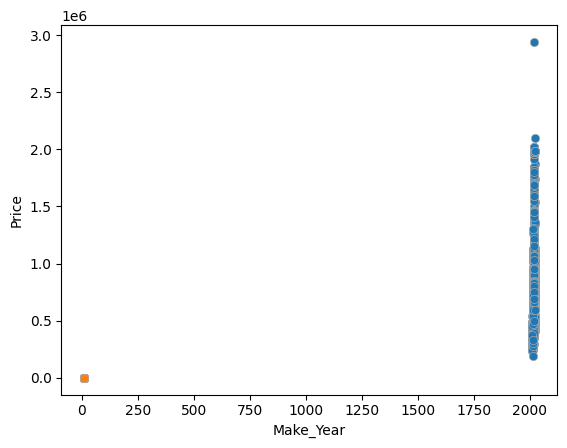

In [10]:
# part 1 code
# load and look at data
car_df = pd.read_csv('/content/drive/MyDrive/DS3001/data/cars_hw.csv')
print(car_df.head())
# strip whitespace from col names and str vals
car_df.columns = car_df.columns.str.strip()
for col in car_df.select_dtypes(include="object").columns:
    car_df[col] = car_df[col].astype(str).str.strip() # unnamed is just count for obs
     # look at cols
print(car_df.dtypes)
# summary stats
print("Cars Summary:\n", car_df.describe())
print("Missing values:\n", car_df.isna().sum())
print("Unique values:\n", car_df.nunique())
print("Cars Info:\n", car_df.info())
# hist for dist
car_df.hist(figsize=(12,10))
plt.show()
for col in car_df.select_dtypes(include='number').columns:
    sns.scatterplot(x=car_df[col], y=car_df['Price'])
    plt.title(col)
    plt.show()
# boxplot
for col in car_df.select_dtypes(include='number').columns:
    sns.boxplot(x=car_df[col])
    plt.title(col)
    plt.show()
# price scatterplot
sns.scatterplot(data=car_df,y='Price',x='Make_Year',edgecolor='darkgrey')
# CHANGES/transformations
car_df = car_df.drop(columns=['Unnamed: 0'])
car_df['log_price'] = np.log(car_df['Price'])
car_df['asinh_mileage'] = np.arcsinh(car_df['Mileage_Run'])
car_df['Seating_Capacity'] = car_df['Seating_Capacity'].astype('category')

I first chose to elimate the unamed column becuase that was just the count/identity for each observation. Then, looking at Price (the later response variable), it showed a strong right skew with increasing variance with predictors. So, I chose to apply a log-transformation. Mileage_Run also showed right skewness and nonlinearity (when compared with Price), so I performed an arcsinh transformation to stabilize variance while maintaining zero values. Seating-Capacity is a categorical variable, as it discrete, so I encoded it as such.

  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?


Summarize Price:
 count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


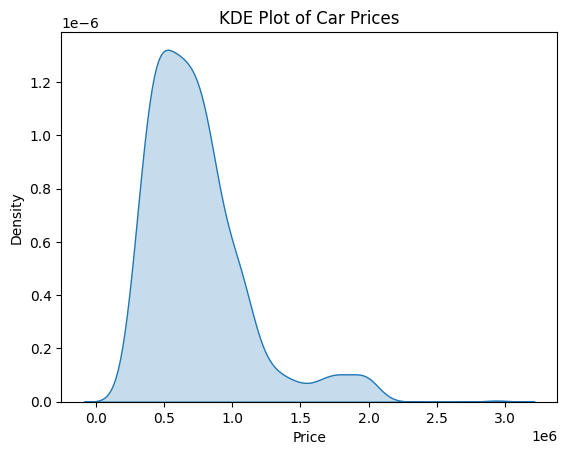

Summarize Price by Make:
                count          mean           std        min        25%  \
Make                                                                     
Chevrolet        6.0  4.535000e+05  2.466064e+05   267000.0   288500.0   
Datsun           3.0  2.896667e+05  1.050397e+04   279000.0   284500.0   
Ford            52.0  7.211731e+05  1.409277e+05   290000.0   635000.0   
Honda           73.0  7.989726e+05  2.665091e+05   316000.0   581000.0   
Hyundai        305.0  6.918918e+05  2.791597e+05   248000.0   485000.0   
Jeep             4.0  1.499500e+06  1.525134e+05  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  1.190567e+05  1369000.0  1579000.0   
MG Motors       35.0  1.869457e+06  1.216611e+05  1589000.0  1786500.0   
Mahindra        18.0  1.100167e+06  1.755493e+05   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  2.160199e+05   237000.0   411000.0   
Nissan           4.0  8.842500e+05  2.895599e+05   475000.0   782500.0   
Renault     

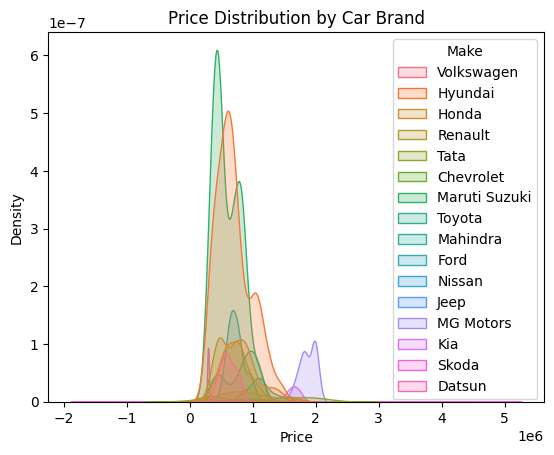

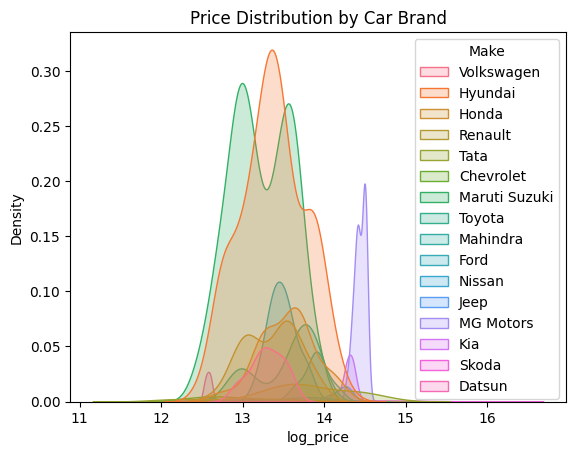

Median Price (High to Low):
 Make
MG Motors        1848000.0
Kia              1628500.0
Jeep             1529500.0
Mahindra         1094500.0
Nissan            978000.0
Toyota            894000.0
Tata              869000.0
Honda             785000.0
Ford              707500.0
Renault           644000.0
Hyundai           638000.0
Volkswagen        607000.0
Skoda             538000.0
Maruti Suzuki     527000.0
Chevrolet         345500.0
Datsun            290000.0
Name: Price, dtype: float64


In [26]:
# part 2 code
# summarize price only
print("Summarize Price:\n",car_df['Price'].describe())
# create KDE
sns.kdeplot(car_df['Price'], fill=True)
plt.title("KDE Plot of Car Prices")
plt.xlabel("Price")
plt.show()
# summarize price by make
print("Summarize Price by Make:\n",car_df.groupby('Make')['Price'].describe())
# grouped KDE
sns.kdeplot(data=car_df, x='Price', hue='Make', fill=True)
plt.title("Price Distribution by Car Brand")
plt.show()
# KDE of transformed price: log_price
car_df['log_price'] = np.log(car_df['Price'])
sns.kdeplot(data=car_df, x='log_price', hue='Make', fill=True)
plt.title("Price Distribution by Car Brand")
plt.show()
# sort cars by median price
print("Median Price (High to Low):\n",car_df.groupby('Make')['Price'].median().sort_values(ascending=False))

It seems that MG motors is the most expensive, followed by Kia and Jeep. Overall, most prices are in the range of $60,000-$100,000 cars. From the KDE plots, we can see that they tend to have peaks in a similar range.

  3. Split the data into an 80% training set and a 20% testing set.


In [16]:
# part 3 code
# response
y = car_df['Price']
# predictors only
X = car_df.drop(columns=['Price'])
# num and cat predictor sets
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
# verify
print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)
# split data into 80/20 train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

Numeric columns: ['Unnamed: 0', 'Make_Year', 'Mileage_Run', 'Seating_Capacity', 'price_ihs', 'make_year_ihs']
Categorical columns: ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']


  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?


In [35]:
# part 4 code
# model 1 with num vars only
X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

model_num = LinearRegression()
model_num.fit(X_train_num, y_train)

# predictions
yhat_train_num = model_num.predict(X_train_num)
yhat_test_num = model_num.predict(X_test_num)

# r2 and rmse
r2_train_num = r2_score(y_train, yhat_train_num)
r2_test_num = r2_score(y_test, yhat_test_num)

rmse_train_num = np.sqrt(mean_squared_error(y_train, yhat_train_num))
rmse_test_num = np.sqrt(mean_squared_error(y_test, yhat_test_num))

print("Numeric-only model")
print("Train R2:", r2_train_num)
print("Test R2:", r2_test_num)
print("Train RMSE:", rmse_train_num)
print("Test RMSE:", rmse_test_num)
# model 2: cat vars (one-hot-encode)
X_train_cat = pd.get_dummies(X_train[cat_cols], drop_first=True)
X_test_cat = pd.get_dummies(X_test[cat_cols], drop_first=True)
# make sure train/test have same columns
X_train_cat, X_test_cat = X_train_cat.align(X_test_cat, join='left', axis=1, fill_value=0)
# fit model
model_cat = LinearRegression()
model_cat.fit(X_train_cat, y_train)
# find yhat
yhat_test_cat = model_cat.predict(X_test_cat)
# r2 and rmse
r2_test_cat = r2_score(y_test, yhat_test_cat)
rmse_test_cat = np.sqrt(mean_squared_error(y_test, yhat_test_cat))
print("\nCategorical-only model")
print("Test R2:", r2_test_cat)
print("Test RMSE:", rmse_test_cat)

# joint model
# one-hot encode categorical part
X_train_cat_full = pd.get_dummies(X_train[cat_cols], drop_first=True)
X_test_cat_full = pd.get_dummies(X_test[cat_cols], drop_first=True)
X_train_cat_full, X_test_cat_full = X_train_cat_full.align(
    X_test_cat_full, join='left', axis=1, fill_value=0)
# combine with numeric part
X_train_joint = pd.concat([X_train[num_cols].reset_index(drop=True),
                           X_train_cat_full.reset_index(drop=True)], axis=1)
X_test_joint = pd.concat([X_test[num_cols].reset_index(drop=True),
                          X_test_cat_full.reset_index(drop=True)], axis=1)
model_joint = LinearRegression()
model_joint.fit(X_train_joint, y_train)
yhat_test_joint = model_joint.predict(X_test_joint)
r2_test_joint = r2_score(y_test, yhat_test_joint)
rmse_test_joint = np.sqrt(mean_squared_error(y_test, yhat_test_joint))
print("\nJoint model")
print("Test R2:", r2_test_joint)
print("Test RMSE:", rmse_test_joint)

Numeric-only model
Train R2: 0.9230644870000296
Test R2: 0.9198406246519457
Train RMSE: 103627.72229771913
Test RMSE: 95884.92185577349

Categorical-only model
Test R2: 0.7086843554399442
Test RMSE: 182791.1060130852

Joint model
Test R2: 0.9629002486054643
Test RMSE: 65231.693907133296


The joint model performs better than both the numeric-only and categorical-only models. The joint model has a higher $R^2=0.9629$, the numeric has $R^2=0.9198$, and categorical has $R^2=0.7086$. The Joint model also has lower RMSE=65231.69, where the numeric has RMSE=95884.92, and categorical has RMSE=182791.11. Becuase $R^2$ will always increase with added predictors, the joint model also having a significant decrease in RMSE is indicative that having both the categorical and numeric predictors present explain more information on our response variable, Price.

  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?


In [37]:
# part 5 code
# polynom expan of num vars
from sklearn.preprocessing import PolynomialFeatures
results = []
for deg in range(1, 11):
  poly = PolynomialFeatures(degree=deg, include_bias=False)
  X_train_poly = poly.fit_transform(X_train_num)
  X_test_poly = poly.transform(X_test_num)
  model_poly = LinearRegression()
  model_poly.fit(X_train_poly, y_train)
  yhat_train_poly = model_poly.predict(X_train_poly)
  yhat_test_poly = model_poly.predict(X_test_poly)
  r2_train_poly = r2_score(y_train, yhat_train_poly)
  r2_test_poly = r2_score(y_test, yhat_test_poly)
  rmse_train_poly = np.sqrt(mean_squared_error(y_train, yhat_train_poly))
  rmse_test_poly = np.sqrt(mean_squared_error(y_test, yhat_test_poly))
  results.append({
      "degree": deg,
      "train_r2": r2_train_poly,
      "test_r2": r2_test_poly,
      "train_rmse": rmse_train_poly,
      "test_rmse": rmse_test_poly,
      "n_features": X_train_poly.shape[1]
    })
results_df = pd.DataFrame(results)
print(results_df)
# test when R2 turns neg
neg_r2 = results_df[results_df['test_r2'] < 0]
if len(neg_r2) > 0:
    first_negative_degree = neg_r2.iloc[0]['degree']
    print("First degree where R2 goes negative:", first_negative_degree)
else:
    print("Test R2 does not negative")

# find best poly model
best_poly_r2_row = results_df.loc[results_df['test_r2'].idxmax()]
best_poly_rmse_row = results_df.loc[results_df['test_rmse'].idxmin()]
print("\nBest polynomial model by test R2:")
print(best_poly_r2_row)
print("\nBest polynomial model by test RMSE:")
print(best_poly_rmse_row)

   degree  train_r2   test_r2     train_rmse      test_rmse  n_features
0       1  0.923064  0.919841  103627.722298   95884.921842           6
1       2  0.997065  0.996724   20241.165313   19384.060445          27
2       3  0.997907  0.997506   17094.091226   16911.391147          83
3       4  0.989573  0.988711   38149.592521   35982.606022         209
4       5  0.973139  0.967396   61230.936674   61151.990854         461
5       6  0.861731  0.847141  138923.047003  132409.451589         923
6       7  0.767579  0.741455  180115.088722  172203.276855        1715
7       8  0.476517  0.183542  270311.129111  306013.197599        3002
8       9  0.387952  0.048559  292284.230677  330342.264767        5004
9      10  0.320334 -0.178449  308006.714889  367644.941317        8007
First degree where test R2 goes negative: 10.0

Best polynomial model by test R2:
degree            3.000000
train_r2          0.997907
test_r2           0.997506
train_rmse    17094.091226
test_rmse     1691

The first degree where the $R^2$ on the test set goes negative is the 10th degree. While the $R^2$ increased from 0.9629 on the joint model to 0.9979 in the polynomial model, the RMSE also increased from 65231.69 on the joint model to 16911.39 in the polynomial model. Knowing that $R^2$ will always increase with added terms, I would suggest using the joint model instead of the polynomial model because of the simplicity and RMSE.

  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

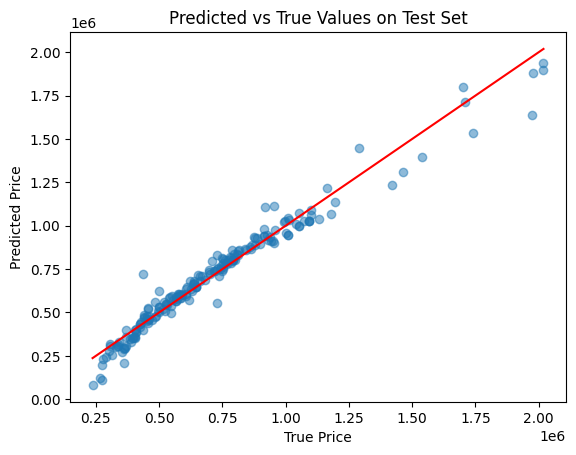

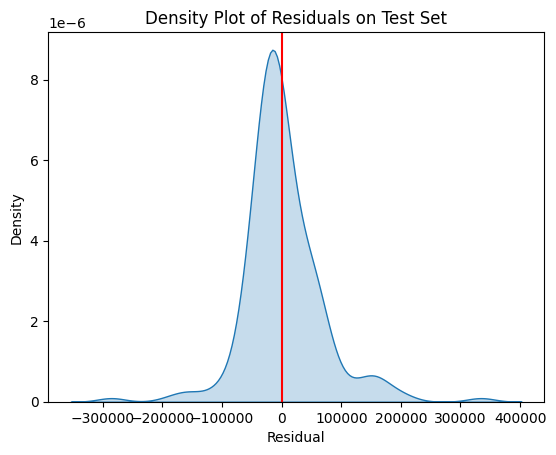

In [39]:
# part 6 code
# best model: joint model
# second highest r2 and lowest rmse
# get predictions from joint model
yhat_test = model_joint.predict(X_test_joint)
# scatter plot w/diagonal line
plt.scatter(y_test, yhat_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs True Values on Test Set")
plt.show()
# compute residuals
residuals = y_test - yhat_test
# create KDE of residuals
sns.kdeplot(x=residuals, fill=True)
plt.axvline(0, color='red')
plt.title("Density Plot of Residuals on Test Set")
plt.xlabel("Residual")
plt.show()

From the scatterplot, the predicted vs true values follows the diagnol line closley. This is suggestive that the model captures the relationship between oredictors and price. Further, we can see the increase in dispersion/spread for more expensice cars, which suggests reduced accuracy for higher values of the price variable.


In the KDE plot of residuals, the distribution is unimodal and centered around 0. However the peak is slightly left of zero, which suggests that the model might overpredict. Further, the residual distribution shows some right skewness which could be a sign of underprediction for expensive vehicles, similar to what is seen in the scatterplot. Overall, the joint model captures the main trends in our cars data.

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.

$SSE(b_0,b_1,b_2)=∑_{i=1}^{N}(y_i-b_0-b_1z_{i1}-b_2z_{i2})^2$

2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.

Let the residuals, $e_i$ be defined as $e_i :=y_i-\hat y = y_i-b_0-b-1z_{i1}-b_2z_{i2}$.

$\frac{\delta SSE}{δ b_0}=0$ implies $-2∑_{i=1}^{N}(y_i-b_0-b_1z_{i1}-b_2z_{i2})$, by def'n of $e_i$, we have that the RHS is equal to $-2∑_{i=1}^{N}(e_i)$.

$\frac{\delta SSE}{δ b_1}=0$ implies $-2∑_{i=1}^{N}(y_i-b_0-b_1z_{i1}-b_2z_{i2})=-2∑_{i=1}^{N}(z_{i1}e_i)$, by the def'n of $e_i$.

$\frac{\delta SSE}{δ b_2}=0$ implies $-2∑_{i=1}^{N}(y_i-b_0-b_1z_{i1}-b_2z_{i2})=-2∑_{i=1}^{N}(z_{i2}e_i)$, by the def'n of $e_i$.

3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.

Verify (i) $\frac{1}{N}∑_{i=1}^{N}(e_i)=0$ (residuals sum to 0), (ii)$\frac{1}{N}∑_{i=1}^{N}(z_{ij}e_i)=0, (j=1,2)$ (residuals are orthogonal to predictors).

(i) Using the result from $\frac{\delta SSE}{δ b_0}=0$, we have that $∑_{i=1}^{N}(e_i)=0$, therefore $\frac{1}{N}∑_{i=1}^{N}(e_i)$.

(ii) From $\frac{\delta SSE}{δ b_1}=0$, we have that $∑_{i=1}^{N}(z_{i1}e_i)=0$. And from $\frac{\delta SSE}{δ b_2}=0$, we have $∑_{i=1}^{N}(z_{i2}e_i)=0$. Thus, $\frac{1}{N}∑_{i=1}^{N}(z_{ij}e_i)=0, (j=1,2)$, showing $e*z=0$ at the optimum.

4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.

$∑_{i=1}^{N}(y_i-b_0-b_1z_{i1}-b_2z_{i2})=∑_{i=1}^{N}y_i-∑_{i=1}^{N}b_0-b_1∑_{i=1}^{N}z_{i1}-b_2∑_{i=1}^{N}z_{i2}=0$.

Knowing $∑_{i=1}^{N}b_0=Nb_0,∑_{i=1}^{N}z_{i1}=0, ∑_{i=1}^{N}z_{i2}=0 $, we can express the LHS as $∑_{i=1}^{N}y_i-Nb_0-b_1∑_{i=1}^{N}z_{i1}-b_2∑_{i=1}^{N}z_{i2}=∑_{i=1}^{N}y_i-Nb_0=0$. Thus, $b^*_0=\frac{1}{N}∑_{i=1}^{N}y_i=\bar y$

Eliminate $b_0^*$ from the remaining equations:

$b_1=∑_{i=1}^{N}z_{i1}(y_i-\bar y-b_1z_{i1}-z_{i2})=0$ can be written as

$∑_{i=1}^{N}z_{i1}(y_i-\bar y)-b_i∑_{i=1}^{N}z_{i1}^2-b_2∑_{i=1}^{N}z_{i1}z_{i2}=0$. So, $b_i∑_{i=1}^{N}z_{i1}^2-b_2∑_{i=1}^{N}z_{i1}z_{i2}=∑_{i=1}^{N}z_{i1}(y_i-\bar y)=∑_{i=1}^{N}z_{i1}y_i$

$b_2=∑_{i=1}^{N}z_{i2}(y_i-\bar y-b_1z_{i1}-z_{i2})=0$ can be written as $∑_{i=1}^{N}z_{i2}(y_i-\bar y)-b_1∑_{i=1}^{N}z_{i1}z_{i2}-b_2∑_{i=1}^{N}z_{i2}^2=0$. Thus, ∑_{i=1}^{N}z_{i2}(y_i-\bar y)-∑_{i=1}^{N}z_{i2}y_1$


5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.

Let $b=\begin{pmatrix} b_1 \\ b_2 \end{pmatrix}$. Then, $\begin{pmatrix}∑_{i=1}^{N}z_{i1}^2 & ∑_{i=1}^{N}z_{i1}z_{i2} \\ ∑_{i=1}^{N}z_{i1}z_{i2} & ∑_{i=1}^{N}z_{i2}^2\end{pmatrix}\begin{pmatrix} b_1 \\ b_2 \end{pmatrix}= \begin{pmatrix}∑_{i=1}^{N}z_{i1}y_i \\ ∑_{i=1}^{N}z_{i2}y_i\end{pmatrix}$.

6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.
$\begin{pmatrix}\frac{1}{N}∑_{i=1}^{N}z_{i1}^2 & \frac{1}{N}∑_{i=1}^{N}z_{i1}z_{i2} \\ \frac{1}{N}∑_{i=1}^{N}z_{i1}z_{i2} & \frac{1}{N}∑_{i=1}^{N}z_{i2}^2\end{pmatrix}\begin{pmatrix} b_1 \\ b_2 \end{pmatrix}= \begin{pmatrix}\frac{1}{N}∑_{i=1}^{N}z_{i1}y_i \\ \frac{1}{N}∑_{i=1}^{N}z_{i2}y_i\end{pmatrix}$

Let $z_{ij}=x_{ij}-m_j$, we have:
$\frac{1}{N}∑_{i=1}^{N}z_{i1}^2=\frac{1}{N}∑_{i=1}^{N}(x_{i1}-m_1)^2=\widehat{Var}(x_1)$

$\frac{1}{N}∑_{i=1}^{N}z_{i2}^2= \frac{1}{N}∑_{i=1}^{N}(x_{i2}-m_2)^2=\widehat{ Var}(x_2)$


$\frac{1}{N}∑_{i=1}^{N}z_{i1}z_{i2}=\frac{1}{N}∑_{i=1}^{N}(x_{i1}-m_1)(x_{i2}-m_2)= \widehat{Cov}(x_1,x_2)$

$\frac{1}{N}∑_{i=1}^{N}z_{i1}y_i=\frac{1}{N}∑_{i=1}^{N}(x_{i1}-m_1)y_i=\frac{1}{N}∑_{i=1}^{N}(x_{i1}-m_1)(y_i-\bar y)=\widehat{Cov}(x_1,y)$

$\frac{1}{N}∑_{i=1}^{N}z_{i2}y_i=\frac{1}{N}∑_{i=1}^{N}(x_{i2}-m_2)y_i=\frac{1}{N}∑_{i=1}^{N}(x_{i2}-m_2)(y_i-\bar y)=\widehat{Cov}(x_2,y)$

Thus, $\begin{pmatrix} \widehat{Var}(x_1) & \widehat{Cov}(x_1,x_2) \\ \widehat{Cov}(x_1,x_2) & \widehat{Var}(x_2)\end{pmatrix}\begin{pmatrix} b_1 \\ b_2 \end{pmatrix} = \begin{pmatrix}\widehat{Cov}(x_1,y) \\ \widehat{Cov}(x_2,y) \end{pmatrix}$

The matrix $A$ summarizes the structure of dependence of the predictors, where vector $C$ shows each predictor's marginal relationship with the response. Solving $Ab=C$ is synomous to $y=Xβ+ϵ$, which is the general matrix form for linear models. Taking Linear Models (STAT 4120) provided me the intuition to recognize this equation and understand why it is more than a correlation matrix and that it helps adjust for the relationships between predictors. The main signal for this is that the regression coefficients are chosen such that the combined effect of the predictors is what produces their relationships with y, while also accounting for overlap between other predictors.